In [107]:
import pandas as pd

In [108]:
# 1- قراءة جداول قاعدة البيانات
attendance_df = pd.read_csv(r'datasets/attendance_logs_updated.csv')
employees_df = pd.read_csv(r'datasets/employees_dataset_final_with_shifts.csv')
vacations_df = pd.read_csv(r'datasets/vacation_requests_updated.csv')
vacations_df.head()

,id,emp_id,processed_by,processed_at,requested_at,start_date,end_date,reason,approval_status
0,0,273,00000000-0000-0000-0000-000000000000,2025-01-21,2025-01-21,2025-01-30,2025-02-02,Annual,1
1,1,1300,00000000-0000-0000-0000-000000000000,2025-06-01,2025-06-01,2025-06-08,2025-06-15,Sick,1
2,2,359,00000000-0000-0000-0000-000000000000,2025-05-23,2025-05-23,2025-06-05,2025-06-12,Annual,2
3,3,966,00000000-0000-0000-0000-000000000000,2025-08-03,2025-08-03,2025-08-11,2025-08-19,Maternity/Paternity,1
4,4,605,00000000-0000-0000-0000-000000000000,2025-05-16,2025-05-16,2025-05-21,2025-05-23,Unpaid,1


الأعمدة التي سيتم حسابها:
attrition,
attrition_risk_class_id, 
over_time_hours_last_month, 
late_arrivals_last_month, 
absence_days_last_month, 
absence_ratio, 


employees_df.drop(columns=['xx'], inplace=True)
employees_df.loc[0,'xx']='HI'


What can we predict?
- attrition (who will leave)

- promotion: years_since_last_promotion
features: performance, engagement, tenure

- performance: performance_rating_id
features: engagement, workload, training, overtime


| Model       | Type                        |
| ----------- | --------------------------- |
| Attrition   | Classification              |
| Promotion   | Regression / Classification |
| Performance | Classification              |
 


Very important issue in the dataset:

attrition = mostly “No”
performance_rating_id = maybe mostly “3”

You must handle:

class imbalance
stratified split
proper metrics

Use:

F1-score
ROC-AUC
confusion matrix

NOT just accuracy.


In [109]:
# 3- حساب دقائق التأخر ودقائق العمل الإضافي لكل موظف
# grace period = 15 mins

In [110]:
#- إضافة حقلي: الإجازات المقبولة، والإجازات المرفوضة، لجدول الموظفين
employees_df['accepted_vacations'] = 0
employees_df['rejected_vacations'] = 0

for emp in employees_df.itertuples():
    acc_vac = 0
    rej_vac = 0

    for vac in vacations_df.itertuples():
        if vac.emp_id == emp.id:
            if vac.approval_status:
                acc_vac += 1
            else:
                rej_vac += 1

    employees_df.loc[
        employees_df['id'] == emp.id,
        'accepted_vacations'
    ] = acc_vac

    employees_df.loc[
        employees_df['id'] == emp.id,
        'rejected_vacations'
    ] = rej_vac

employees_df.to_csv('employees_ml.csv',index=False)

In [111]:
# attendance_df.loc[attendance_df['shift_id']==1].head(200)
print(type(attendance_df.check_in[0]))

<class 'str'>


In [112]:
employees_df.columns

Index(['id', 'name', 'name_code', 'attrition', 'age', 'gender',
       'marital_status_id', 'distance_from_home', 'hourly_rate', 'daily_rate',
       'monthly_rate', 'monthly_income', 'percent_salary_hike', 'job_level',
       'job_role_id', 'business_travel_id', 'department_id', 'education_id',
       'num_of_companies_worked', 'total_working_years',
       'training_times_last_year', 'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager',
       'stock_option_level', 'environment_satisfaction_id',
       'job_involvement_id', 'job_satisfaction_id', 'performance_rating_id',
       'relationship_satisfaction_id', 'work_life_balance_id', 'over_time',
       'workload_pressure_index', 'engagement_score',
       'engagement_feedback_score', 'training_hours_last_year',
       'training_hours_last_6_months', 'training_gap_score',
       'promotion_stagnation_ratio', 'role_stability_ratio',
       'attrition_risk_class_id', 'over_time_hour

In [113]:
employees_df['absence_ratio'][951]

np.float64(0.0434782608695652)

In [114]:
# employees_df.drop('attretion')
vacations_df.head()

,id,emp_id,processed_by,processed_at,requested_at,start_date,end_date,reason,approval_status
0,0,273,00000000-0000-0000-0000-000000000000,2025-01-21,2025-01-21,2025-01-30,2025-02-02,Annual,1
1,1,1300,00000000-0000-0000-0000-000000000000,2025-06-01,2025-06-01,2025-06-08,2025-06-15,Sick,1
2,2,359,00000000-0000-0000-0000-000000000000,2025-05-23,2025-05-23,2025-06-05,2025-06-12,Annual,2
3,3,966,00000000-0000-0000-0000-000000000000,2025-08-03,2025-08-03,2025-08-11,2025-08-19,Maternity/Paternity,1
4,4,605,00000000-0000-0000-0000-000000000000,2025-05-16,2025-05-16,2025-05-21,2025-05-23,Unpaid,1


In [115]:
appr= 0
n_appr = 0
for emp in employees_df.itertuples():
    for vac_req in vacations_df.itertuples():
        if vac_req.emp_id == emp.id:
            if vac_req.approval_status:
                appr+=1
            else: 
                n_appr+=1
    print(emp.id,' ',appr," ",n_appr)
    appr=0
    n_appr=0



0   4   1
1   2   0
2   2   0
3   2   0
4   0   0
5   1   2
6   1   0
7   2   0
8   3   0
9   1   0
10   0   1
11   1   0
12   1   0
13   0   0
14   0   0
15   0   0
16   1   0
17   1   0
18   3   0
19   3   0
20   1   0
21   1   0
22   1   0
23   0   0
24   1   1
25   2   0
26   1   0
27   0   0
28   1   0
29   0   0
30   1   0
31   2   0
32   3   0
33   0   0
34   1   0
35   3   0
36   2   0
37   1   0
38   2   1
39   0   0
40   2   0
41   1   0
42   1   0
43   2   1
44   0   0
45   2   0
46   0   0
47   0   1
48   3   0
49   1   1
50   1   0
51   1   1
52   2   0
53   0   0
54   1   0
55   1   1
56   1   0
57   1   0
58   1   0
59   1   0
60   2   0
61   1   0
62   2   0
63   0   0
64   1   0
65   2   0
66   0   0
67   1   0
68   2   0
69   1   0
70   1   0
71   0   1
72   1   1
73   2   0
74   0   0
75   0   0
76   1   0
77   6   0
78   1   0
79   2   0
80   0   0
81   2   0
82   1   0
83   2   0
84   0   0
85   1   0
86   3   1
87   1   1
88   1   0
89   1   0
90   2   0
91   1   

In [121]:
pip install imblearn


   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Best Parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.55      0.26      0.35        47

    accuracy                           0.85       294
   macro avg       0.71      0.61      0.63       294
weighted avg       0.82      0.85      0.82       294

ROC-AUC: 0.771987251270566


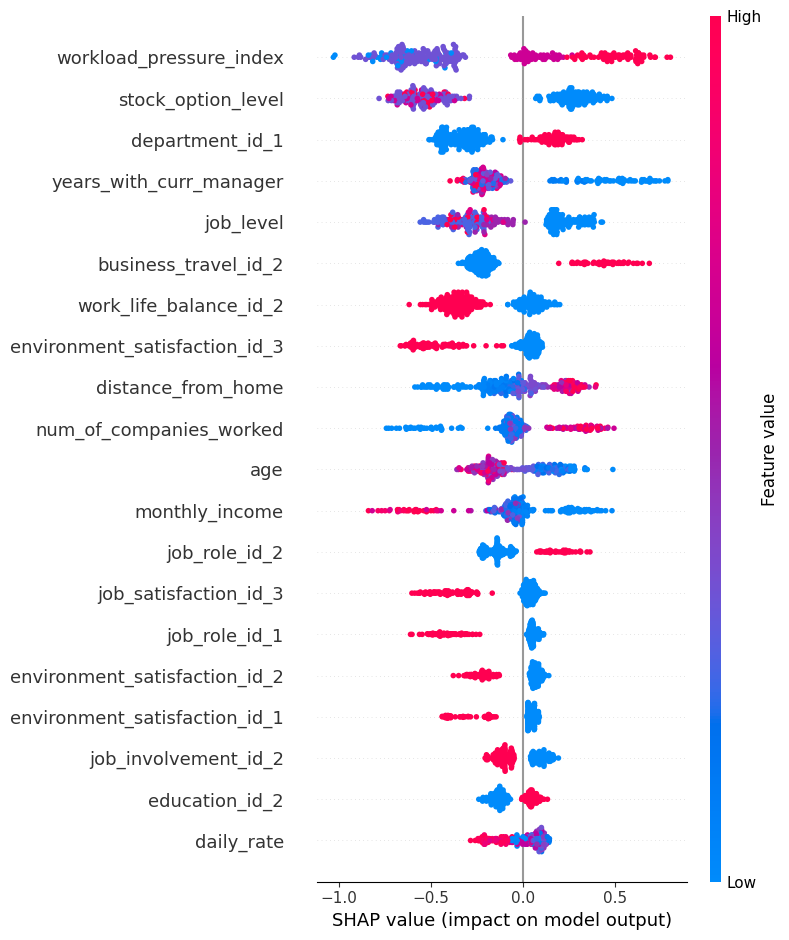

In [122]:
import pandas as pd
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

# Use imblearn Pipeline to prevent data leakage during Cross Validation
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

def build_attrition_pipeline(data_path="employees_ml.csv"):
    # 1. Load Data
    df = pd.read_csv(data_path)

    # 2. Prevent Data Leakage
    cols_to_drop = ['id', 'name', 'name_code', 'attrition_risk_class_id']
    df = df.drop(columns=cols_to_drop)

    # Convert booleans to int for modeling
    bool_cols = df.select_dtypes(include=['bool']).columns
    for col in bool_cols:
        df[col] = df[col].astype(int)

    # 3. Define Features & Target
    X = df.drop(columns=['attrition'])
    y = df['attrition']

    categorical_cols = [
        'marital_status_id', 'job_role_id', 'business_travel_id', 'department_id',
        'education_id', 'environment_satisfaction_id', 'job_involvement_id',
        'job_satisfaction_id', 'performance_rating_id', 'relationship_satisfaction_id',
        'work_life_balance_id', 'work_shift_id'
    ]
    numerical_cols = [col for col in X.columns if col not in categorical_cols]

    # 4. Stratified Split (preserves % of attrition in both sets)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 5. Preprocessing
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

    # 6. Pipeline Construction (Scale/Encode -> SMOTE -> Model)
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
    ])

    # 7. Hyperparameter Tuning & Cross Validation
    param_grid = {
        'classifier__max_depth': [3, 5],            # Prevents overfitting
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__n_estimators': [100, 200]
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid_search = GridSearchCV(
        pipeline, param_grid, cv=cv, scoring='f1', return_train_score=True, n_jobs=-1
    )
    
    # Train
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # 8. Evaluation
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    print(f"Best Parameters: {grid_search.best_params_}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))

    # 9. Explainability with SHAP
    # Transform test set manually to feed purely numeric data into SHAP
    X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)
    feature_names = (numerical_cols + 
                     list(best_model.named_steps['preprocessor']
                          .named_transformers_['cat'].get_feature_names_out(categorical_cols)))
    
    xgb_model = best_model.named_steps['classifier']
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test_transformed)

    # Plot
    shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)
    
    return best_model

if __name__ == "__main__":
    final_model = build_attrition_pipeline()

Training best model (this may take a moment)...

--- Model Evaluation ---
Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
ROC-AUC Score: 0.4926

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       249
           1       0.00      0.00      0.00        45

    accuracy                           0.84       294
   macro avg       0.42      0.50      0.46       294
weighted avg       0.72      0.84      0.78       294


SHAP summary plot saved as 'shap_performance.png'.


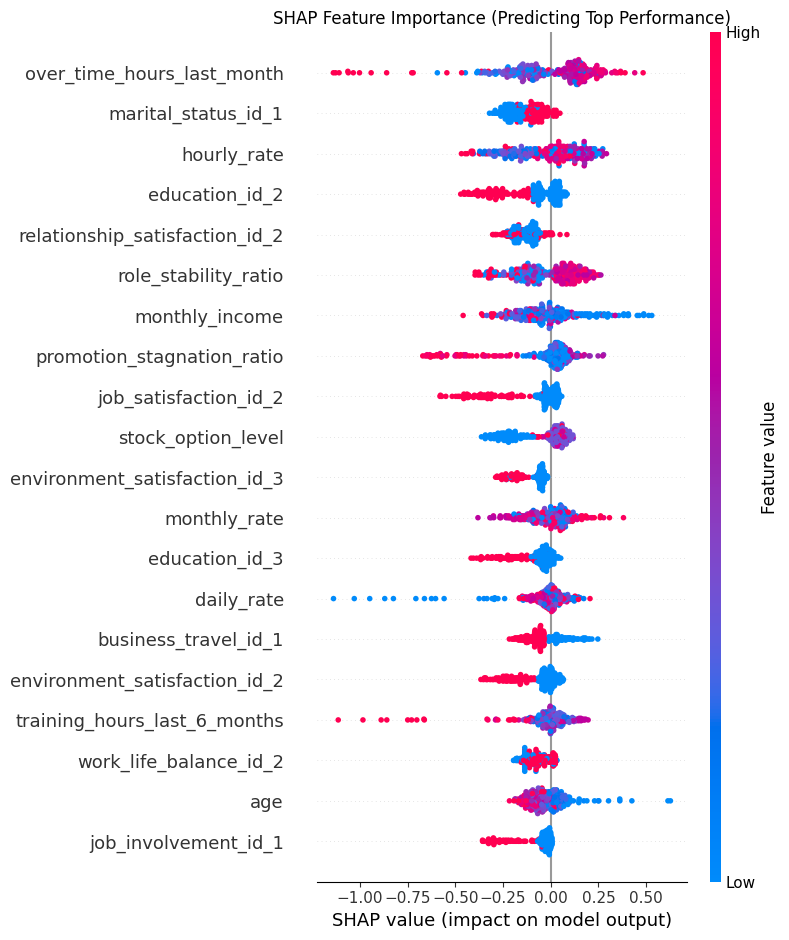

In [123]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, f1_score, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')

def load_and_clean_data(filepath="employees_ml.csv"):
    df = pd.read_csv(filepath)
    
    # 1. Target Mapping (Convert 2/3 to 0/1)
    df['performance_rating_id'] = (df['performance_rating_id'] == 3).astype(int)
    
    # 2. Prevent Target Leakage & Drop Identifiers
    cols_to_drop = ['id', 'name', 'name_code', 'percent_salary_hike', 'engagement_feedback_score']
    df = df.drop(columns=cols_to_drop)
    
    # 3. Format Boolean columns
    bool_cols = df.select_dtypes(include=['bool']).columns
    for col in bool_cols:
        df[col] = df[col].astype(int)
        
    return df

def build_preprocessing_pipeline(X):
    categorical_cols = [
        'marital_status_id', 'job_role_id', 'business_travel_id', 'department_id',
        'education_id', 'environment_satisfaction_id', 'job_involvement_id',
        'job_satisfaction_id', 'relationship_satisfaction_id',
        'work_life_balance_id', 'work_shift_id', 'attrition_risk_class_id'
    ]
    # Keep only categorical columns that actually exist in X
    categorical_cols = [c for c in categorical_cols if c in X.columns]
    numerical_cols = [c for c in X.columns if c not in categorical_cols]
    
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])
    
    return preprocessor, categorical_cols, numerical_cols

def train_and_evaluate_model(df):
    X = df.drop(columns=['performance_rating_id'])
    y = df['performance_rating_id']
    
    # Stratified Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    preprocessor, cat_cols, num_cols = build_preprocessing_pipeline(X)
    
    # Construct Pipeline with SMOTE inside to avoid CV leakage
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
    ])
    
    # Hyperparameter Grid
    param_grid = {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 5],
        'classifier__learning_rate': [0.05, 0.1]
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1)
    
    print("Training best model (this may take a moment)...")
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    
    # Evaluation
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    print("\n--- Model Evaluation ---")
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    return best_model, X_train, X_test

def explain_model(model, X_test):
    # Extract transformations to feed purely numeric data to SHAP
    preprocessor = model.named_steps['preprocessor']
    X_test_transformed = preprocessor.transform(X_test)
    
    cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out()
    num_feature_names = preprocessor.transformers_[0][2]
    all_features = list(num_feature_names) + list(cat_feature_names)
    
    xgb_model = model.named_steps['classifier']
    
    # SHAP Explainability
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test_transformed)
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_transformed, feature_names=all_features, show=False)
    plt.title("SHAP Feature Importance (Predicting Top Performance)")
    plt.tight_layout()
    plt.savefig("shap_performance.png")
    print("\nSHAP summary plot saved as 'shap_performance.png'.")

if __name__ == "__main__":
    dataset = load_and_clean_data()
    final_model, X_train_raw, X_test_raw = train_and_evaluate_model(dataset)
    explain_model(final_model, X_test_raw)